This is the r squared value for A part 1: 1.0
Root Mean Squared Error: 3.706928318730818e-15


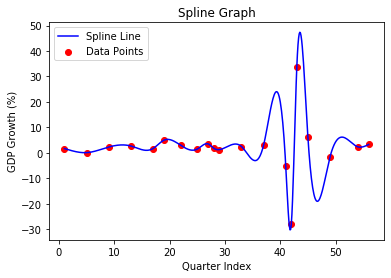

These are the predicted x and y values using the spline: (1,1.7)
These are the predicted x and y values using the spline: (2,1.0525500917855135)
These are the predicted x and y values using the spline: (3,0.5040801468568217)
These are the predicted x and y values using the spline: (4,0.15357012849971896)
These are the predicted x and y values using the spline: (5,0.10000000000000009)
These are the predicted x and y values using the spline: (6,0.402744761357665)
These are the predicted x and y values using the spline: (7,0.9627595594295352)
These are the predicted x and y values using the spline: (8,1.641394577786638)
These are the predicted x and y values using the spline: (9,2.3)
These are the predicted x and y values using the spline: (10,2.8114708627838265)
These are the predicted x and y values using the spline: (11,3.094881615425037)
These are the predicted x and y values using the spline: (12,3.0808515603537296)
These are the predicted x and y values using the spline: (13,2.7)
Th

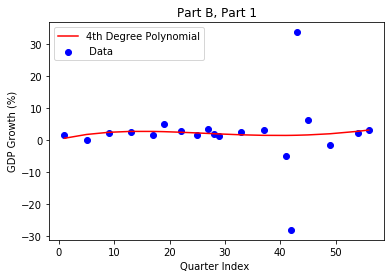

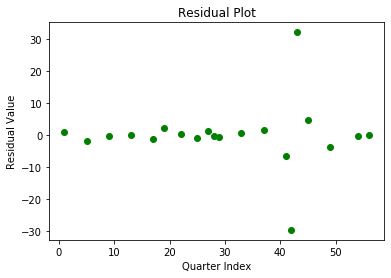

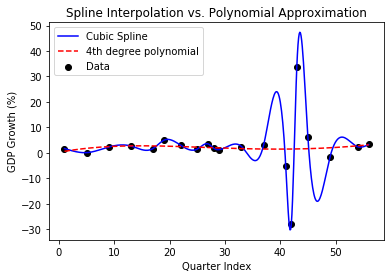

This is the r squared value for B part 2: 0.00044329440682566723
Mean Squared Error: 1.4431864883291987
This is the slope: -0.0019069881889763906


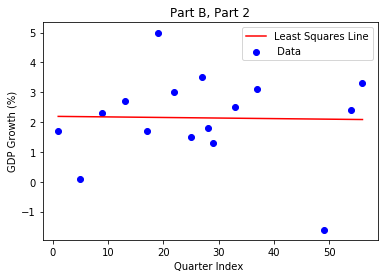

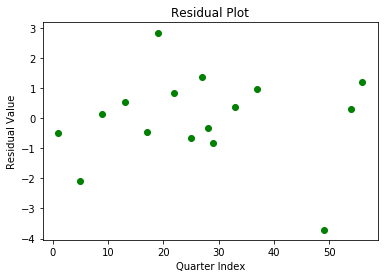

'\nFor a policymaker who would have to interpolate GDP for quarters that are in between two of the data points that we have, I would personally\nrecommend using the cubic spline model. We can look at the results to back up this decision. First looking at the r squared value for the spline tells us that it fits the data perfectly since\nthe vlaue is 1.0, which means it fits the data perfectly. This frankly is what we would expect since the cubic spline is designed\nto go through each and every point on purpose as it is composed of many different equations. This model will fit to outliers independently, meaning the rest of it is \nresistant to outliers allowing interpolation values to be trusted. ALso its root mean squared error is effectively 0, which is incredibly low, further indicating the validity of this model. \nThe reasons not to give preference to the 4th degree polynomial are due to the fact that it is more susceptible to outliers and has to be more of an "average" in a sense a

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import math
x_covid = [1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56]
covid_data = [1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3]

x_non_covid = [1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 49, 54, 56]
non_covid_data = [1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-1.6,2.4,3.3]

x_plot = np.linspace(min(x_covid), max(x_covid), 500)

#Part A
def cubic_spline(x,y):
    h_glob = np.diff(x)
    #Calcualtion our A-D's using the formulas in the slidedeck "Cubic Spline Interpolation". Code is drawn off of old challenge as well. 
    def setup_tridiagonal_matrix(x, y):
        n = len(x)
        h = np.diff(x) # Step sizes between data points
        A = np.zeros(n - 2) 
        B = np.zeros(n - 2) 
        C = np.zeros(n - 2) 
        D = np.zeros(n - 2) 
        
        for i in range(1, n - 1):
            A[i - 1] = h[i-1]
            B[i - 1] = 2*(h[i-1]+h[i])
            C[i - 1] = h[i]
            D[i - 1] = 6*( ((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]))
        return A, B, C, D, h

    A, B, C, D, h_glob= setup_tridiagonal_matrix(x, y)

    #Thomas Algorithm that is based off the equation in the slidedeck "Cubic Spline Redux" that is quicker than regular linalg.solve 
    def thomas_algorithm(a, b, c, d):
        n = len(b)
        for i in range(1, n):
            w = a[i-1] / b[i-1]
            b[i] = b[i] - w * c[i-1]
            d[i] = d[i] - w * d[i-1]
        x = np.zeros(n)
        x[-1] = d[-1] / b[-1]
        for i in range(n-2, -1, -1):
            x[i] = (d[i] - c[i] * x[i+1]) / b[i]
        return x
        
    result = thomas_algorithm(A[1:], B, C[:-1], D)
    # Forcing second derivative values at the two ends to be zero so that it works, thats why it has two [0]'s
    M_list = np.concatenate(([0], result, [0]))

    #This 
    def evaluate_spline(xeval, x, y, M_list, h_glob):
        n = len(x)
        i = 0
        for j in range(n - 1):
            if x[j] <= xeval and  xeval <= x[j+1]:
                i = j
                break   
        dx = xeval - x[i]
        a = y[i]
        b = (y[i+1] - y[i])/h_glob[i] - h_glob[i]*(M_list[i+1] + 2*M_list[i])/6
        c = M_list[i]/2
        d = (M_list[i+1] - M_list[i]) / (6 * h_glob[i])

        return a + b*dx + c*dx**2 + d*dx**3
    # Setting up variables to run statistics calculations and final data output.
    x_plot = np.linspace(x[0], x[-1], 500)
    y_plot = []
    x_inputs = range(1,57)
    ypred_vals = []
    ypred_20 = []
    
    #three for loops to get 1st: the y values for the residuals, 2: The y values for the 20 inputs, 3: The y values for the total 56 predicted one.
    for val in x:
        addy = evaluate_spline(val, x, y, M_list, h_glob)
        ypred_20.append(addy)
    for val in x_plot:
        addy = evaluate_spline(val, x, y, M_list, h_glob)
        y_plot.append(addy)
    for val in x_inputs:
        addy = evaluate_spline(val, x, y, M_list, h_glob)
        ypred_vals.append(addy)

    y_residuals = y - np.array(ypred_20)
    
    # Same R and MSE code as the other sections.
    r_denominator = np.sum((y - np.mean(y))**2)
    r_numerator = np.sum(y_residuals**2)
    r_squared = 1 - (r_numerator / r_denominator)
    mse = np.mean(y_residuals**2)
    rmse = math.sqrt(mse)
    
    print(f"This is the r squared value for A part 1: {r_squared}")    
    print(f"Root Mean Squared Error: {rmse}")    
    #The scatter plot for the spline
    plt.scatter(x, y, color='red', label='Data Points')
    plt.plot(x_plot, y_plot, color='blue', label='Spline Line')
    plt.title('Spline Graph')
    plt.xlabel('Quarter Index')
    plt.ylabel('GDP Growth (%)')
    plt.legend()
    plt.show()
    
    help_counter = 0
    for i in ypred_vals:
        
        print(f"These are the predicted x and y values using the spline: ({x_inputs[help_counter]},{ypred_vals[help_counter]})")
        help_counter += 1
    print("\n")
    return y_plot

y_spline_plot = cubic_spline(x_covid,covid_data)


   




#Start of Part B

def polynomial_fit (x,y):
    x = np.array(x)
    y= np.array(y)
    
    x1 = x 
    x2 = x*x
    x3 = x*x*x
    x4 = x*x*x*x
    #constucting the vandermonde matrix and then solving the normal equations.
    A = np.column_stack(( np.ones(len(x)),x1,x2,x3,x4))
    left_side = A.T @ A
    right_side = A.T @ y
    x_answer = np.linalg.solve(left_side,right_side)
    a_0 = x_answer[0]
    a_1 = x_answer[1]
    a_2 = x_answer[2]
    a_3 = x_answer[3]
    a_4 = x_answer[4]
    y_line = a_0 + (a_1 *x) + (a_2 *(x*x)) + (a_3 *(x*x*x)) + (a_4 *(x*x*x*x))
    y_residuals = y - y_line
    
    #The rsquared and MSE data calculations
    r_denominator = np.sum((y - np.mean(y))**2)
    r_numerator = np.sum(y_residuals**2)
    r_squared = 1 - (r_numerator / r_denominator)
    mse = np.mean(y_residuals**2)
    rmse = math.sqrt(mse)
    
    print(f"This is the r squared value for B part 1: {r_squared}")    
    print(f"Root Mean Squared Error: {rmse}")
    
    #Similar scatter plot output
    plt.scatter(x, y, color='blue', label=' Data') 
    plt.plot(x, y_line, color='red', label='4th Degree Polynomial')    
    plt.xlabel('Quarter Index ')
    plt.ylabel('GDP Growth (%)')
    plt.title('Part B, Part 1')
    plt.legend()
    plt.show()
    plt.figure()
    plt.scatter(x, y_residuals, color='green')
    plt.xlabel('Quarter Index')
    plt.ylabel('Residual Value')
    plt.title('Residual Plot')
    plt.show()
    return a_0,a_1,a_2,a_3,a_4
 
#This is the section that puts the cubic spline and polynomial onto one graph
a0,a1,a2,a3,a4 = polynomial_fit(x_covid,covid_data)
y_poly_plot = a0 + a1*x_plot + a2*x_plot**2 + a3*x_plot**3 + a4*x_plot**4

plt.scatter(x_covid, covid_data, color='black', label='Data')  
plt.plot(x_plot, y_spline_plot, color='blue', label='Cubic Spline') 
plt.plot(x_plot, y_poly_plot, color='red', linestyle='--', label='4th degree polynomial')

plt.xlabel('Quarter Index') 
plt.ylabel('GDP Growth (%)') 
plt.title('Spline Interpolation vs. Polynomial Approximation') 
plt.legend()
plt.show()

def least_squares (x,y):
    #This creates the array manually with a sections of ones and then for x. It then just does matrix multiplicaiton and uses the built in linear algebra solver to get value.
    x = np.array(x)
    y=np.array(y)
    A = np.column_stack((x, np.ones(len(x))))
    left_side = A.T @ A
    right_side = A.T @ y
    x_answer = np.linalg.solve(left_side,right_side)
    m = x_answer[0]
    c = x_answer[1]
    y_line = m*x+c
    y_residuals = y - y_line
    
    #R squared and MSE calculations again.
    r_denominator = np.sum((y - np.mean(y))**2)
    r_numerator = np.sum(y_residuals**2)
    r_squared = 1 - (r_numerator / r_denominator)
    mse = np.mean(y_residuals**2)
    rmse = math.sqrt(mse)
    
    print(f"This is the r squared value for B part 2: {r_squared}")    
    print(f"Mean Squared Error: {rmse}")
    print(f"This is the slope: {x_answer[0]}")
    
    #Graph output for the least squares.
    plt.scatter(x, y, color='blue', label=' Data') 
    plt.plot(x, y_line, color='red', label='Least Squares Line')    
    plt.xlabel('Quarter Index ')
    plt.ylabel('GDP Growth (%)')
    plt.title('Part B, Part 2')
    plt.legend()
    plt.show()
    plt.figure()
    plt.scatter(x, y_residuals, color='green')
    plt.xlabel('Quarter Index')
    plt.ylabel('Residual Value')
    plt.title('Residual Plot')
    plt.show()
    
least_squares(x_non_covid, non_covid_data)

#Start of Part C
"""
For a policymaker who would have to interpolate GDP for quarters that are in between two of the data points that we have, I would personally
recommend using the cubic spline model. We can look at the results to back up this decision. First looking at the r squared value for the spline tells us that it fits the data perfectly since
the vlaue is 1.0, which means it fits the data perfectly. This frankly is what we would expect since the cubic spline is designed
to go through each and every point on purpose as it is composed of many different equations. This model will fit to outliers independently, meaning the rest of it is 
resistant to outliers allowing interpolation values to be trusted. ALso its root mean squared error is effectively 0, which is incredibly low, further indicating the validity of this model. 
The reasons not to give preference to the 4th degree polynomial are due to the fact that it is more susceptible to outliers and has to be more of an "average" in a sense as it is one equation for the entire data set. 
The R Squared value for the 4th degree is zero, which indicated that it predicted 0% of the data points essentially. This makes sense due to the fact that the data is cyclical,
so a straight line going through such data is no good at predicting the values of the dots. Furthermore, the RMSE is 10, which means on average, the models predicitons were off by 10 % points,
which is too high to be be effectively useful. Increasing from n = 4 to a higher one could help make this approach more accurate. 
As for the Least Squares model, the r squared is 0 in this case, which means once again it is a poor predictor since it is single straight line that has to attempt to predict cyclical data tha goes up and down, the complete opposite of linear data.
So clearly the best model is the spline model, which is the one that I would recommend to the policymaker. 

Big O Notation: This is a tool that anaylzes the efficiency and time that a program takes based of how the time scales with the increasing size of "n" its input size.
For this small data set, the differences are meaningless since all algorithms can analyze the data in such a short amonut of time. However, 
for a large scale project that has a bunch of data points, the cubic spline would be better because it stays at O(n) efficiency. The polynomials of high degree will be susceptible to the Runge Phenomenon mentioned and it would take long to solve.
"""







Introduction Paragraph: 
    This project is using computational programming methods to analyze U.S. GDP data that was given to use which is in the form of quarterly reports of GDP growth from 2010-2023.The data gets one quarter of data for each year in the range, except the year 2020 which has 3 quarters of data due to it being a covid year with unusual data. The three methods that will be implemented are Cubic Splines, polynomial fitting, and least squares analysis. These will be used to get different models that can be used to analayze the data and predict the gaps (interpolation) in the data as well as give a picture for future data.

Part A Discussion: 
    In modeling entire data set, I used a cubic spline approach that created individual equation for the spaces in between each data point. This had me solve a triadiagonal system of equations and force the continuity and second derivates at ertian points. The total number of unkowns was based of the number n, which in this case was 20 because that is how many data points we were give. Then the number is n-2 (so 20-2) which comes out to 18 that we need to solve for. These are all the second derivatives at the interior, because we are excluding the beginning and end point. Maintining continuity was important, so along with both sides approaching the same point, they had to have the same second derivative approaching the point as to maintain the fluidity and continuity. The spline is where the two end points second derivatives are zero, which we force. 
    This spline was evaluated across the full range from 2010-2023, which covered 20 data points but a total of 55 x values as the domain. It came out very smooth due to the enforcements put into place as it hit every data point. The part that is questionable is the covid part since it was forced to hit the data point, it doesn't predict what it would have been like if not for covid. The Runge phenomenon comes into play near the covid becuase the graph has to wildly go up and down near the covid points as to hit the outlying covid data. This means that it is a poor predictor right before and after the covid data because of how extreme the graph is. This can be seen in the graph from quarter index range 35-50.
    This is the tradeoff of having exact interpolation at the points as it can be shifted by outliers. Alternatives can be a smooth spline that has less restrictions and minimized residual error, or even a weight least squares that we take more weight off the covid outlier years as to not value them as much, leading to a more accurate curve. 

Part B Discussion: 
    Just as in part a discussion, we once again state that the polynomial is a worse fit than the cubic spline model due to the fact of its r squares value. As for the 4th power polynomial is a better fit than the least squares system, due to the cyclical fact that the data naturally goes up and down, which the polynomial can take into account. The least squares line is stuck to only one direction determined by its slope. Even though the mean squared error is worse for the 4th degree, it is due to the including of the covid outlier data. A linear trend makes the assumption that the economy will maintain only one direction, which goes against natural economic principles. 
    
Conclusion:
    The best approach for interpolation, which is finding the missing data points in between and fitting o each data point, would be the cubic spline because it forces the curve to touch each point. As for the best trend analysis, this would be the polynomial model since it shows the natural fluctuations in the data and isn't forced to hit the outliers since we can't assume all data points are 100% "true". The limits of each approach is that the polynomials can wildly oscillate when the nth power is turned up. Least squares is limited by its ability to only go in one direction with a locked in slope. The Cubic spline is limited by the fact that it is poor at extrapolating data due to it being off by hitting every point that isn't all 100% "true".
    